In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [74]:
file_path = "/Users/sabari/Documents/DS/GUVI/dspatrol/PatrolIQ-Smart_Safety_Analytics_Platform-main/data/Crime_clean.csv"

df = pd.read_csv(file_path)

print(df.shape)
df.head()

(494426, 22)


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13307269,JG540388,12/14/2023 12:01:00 AM,001XX S TROY ST,0820,THEFT,$500 AND UNDER,VACANT LOT / LAND,False,False,...,28.0,27.0,06,1155371.0,1898949.0,2023,12/22/2023 03:41:15 PM,41.878520,-87.704974,"(41.878519796, -87.704973708)"
1,11339480,JB295964,06/06/2018 05:03:00 PM,003XX S HOMAN AVE,1330,CRIMINAL TRESPASS,TO LAND,SIDEWALK,True,False,...,28.0,27.0,26,1153781.0,1897987.0,2018,06/13/2018 04:15:47 PM,41.875912,-87.710838,"(41.875911762, -87.710837503)"
2,2856772,HJ520501,07/25/2003 04:45:00 PM,001XX E DELAWARE PL,0870,THEFT,POCKET-PICKING,HOTEL/MOTEL,False,False,...,42.0,8.0,06,1177786.0,1906673.0,2003,02/28/2018 03:56:25 PM,41.899235,-87.622436,"(41.899235024, -87.622436193)"
3,11912488,JC535868,11/14/2019 08:00:00 AM,031XX S SHIELDS AVE,1110,DECEPTIVE PRACTICE,BOGUS CHECK,"SCHOOL, PRIVATE, BUILDING",False,False,...,11.0,34.0,11,1174469.0,1884050.0,2019,12/08/2019 03:57:40 PM,41.837231,-87.635295,"(41.837230767, -87.635295009)"
4,10941360,JA259248,05/11/2017 11:18:00 AM,008XX N LOCKWOOD AVE,1821,NARCOTICS,MANU/DEL:CANNABIS 10GM OR LESS,SIDEWALK,True,False,...,37.0,25.0,18,1140872.0,1904987.0,2017,02/10/2018 03:50:01 PM,41.895368,-87.758063,"(41.895367769, -87.75806298)"


In [75]:
geo_df = df[['Latitude','Longitude']].dropna()

print("Geo Dataset Shape:", geo_df.shape)

Geo Dataset Shape: (494426, 2)


In [76]:
cluster_sample = geo_df.sample(100000, random_state=42)
#cluster_sample = cluster_sample[cluster_sample['Latitude'] >= 37]

cluster_sample.head()

,Latitude,Longitude
402043,41.895849,-87.680687
168442,41.866261,-87.718553
307255,41.786945,-87.615787
220323,41.771346,-87.679670
90875,41.715942,-87.630939


In [77]:
inertia = []

K_range = range(2,10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_sample)
    inertia.append(kmeans.inertia_)

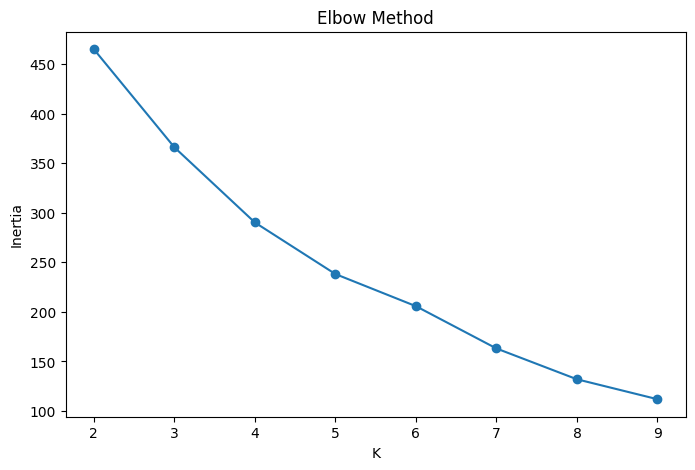

In [78]:
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")

plt.show()

In [79]:
kmeans = KMeans(n_clusters=5, random_state=42)

cluster_sample['KMeans_Cluster'] = kmeans.fit_predict(cluster_sample)

In [80]:
sil_sample = cluster_sample.sample(20000, random_state=42)

score = silhouette_score(
    sil_sample[['Latitude','Longitude']],
    sil_sample['KMeans_Cluster']
)

print("KMeans Silhouette Score:", score)

KMeans Silhouette Score: 0.38655299574536667


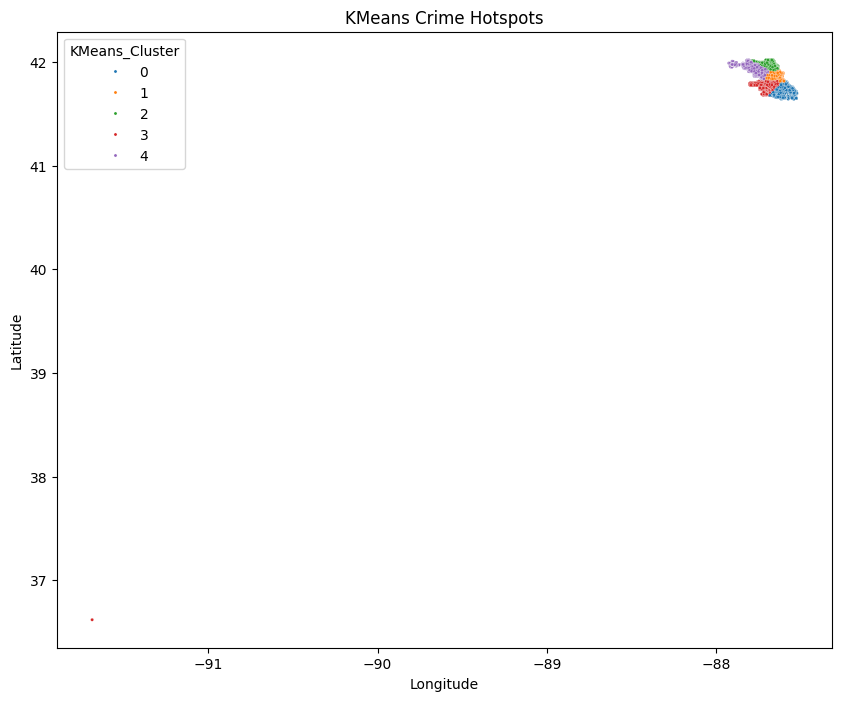

In [81]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    x=cluster_sample['Longitude'],
    y=cluster_sample['Latitude'],
    hue=cluster_sample['KMeans_Cluster'],
    palette='tab10',
    s=5
)

plt.title("KMeans Crime Hotspots")
plt.show()

In [82]:
db = DBSCAN(eps=0.005, min_samples=40)

cluster_sample['DBSCAN_Cluster'] = db.fit_predict(cluster_sample)

In [83]:
db_sil_sample = cluster_sample.sample(20000, random_state=42)

if len(set(db_sil_sample['DBSCAN_Cluster'])) > 1:
    db_score = silhouette_score(
        db_sil_sample[['Latitude','Longitude']],
        db_sil_sample['DBSCAN_Cluster']
    )
    print("DBSCAN Silhouette:", db_score)
else:
    print("DBSCAN produced single cluster / noise")

DBSCAN Silhouette: 0.15239033939431154


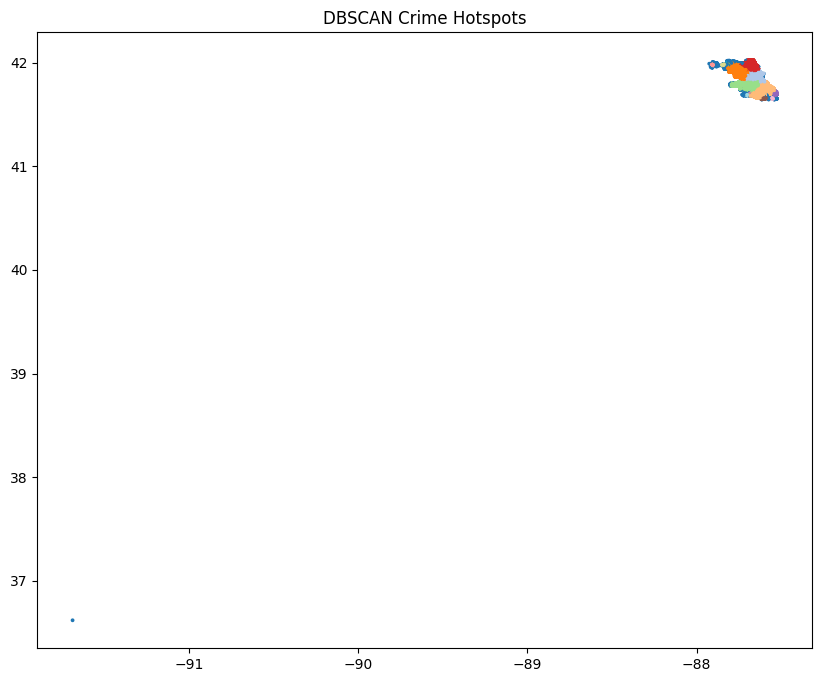

In [84]:
plt.figure(figsize=(10,8))

plt.scatter(
    cluster_sample['Longitude'],
    cluster_sample['Latitude'],
    c=cluster_sample['DBSCAN_Cluster'],
    cmap='tab20',
    s=3
)

plt.title("DBSCAN Crime Hotspots")
plt.show()

In [85]:
cluster_sample_small = cluster_sample.sample(5000, random_state=42)

hc = AgglomerativeClustering(n_clusters=5)

cluster_sample_small['Hierarchical_Cluster'] = hc.fit_predict(
    cluster_sample_small[['Latitude','Longitude']]
)

In [86]:
score = silhouette_score(
    cluster_sample_small[['Latitude','Longitude']],
    cluster_sample_small['Hierarchical_Cluster']
)

print("Hierarchical Silhouette:", score)

Hierarchical Silhouette: 0.30108551507464193


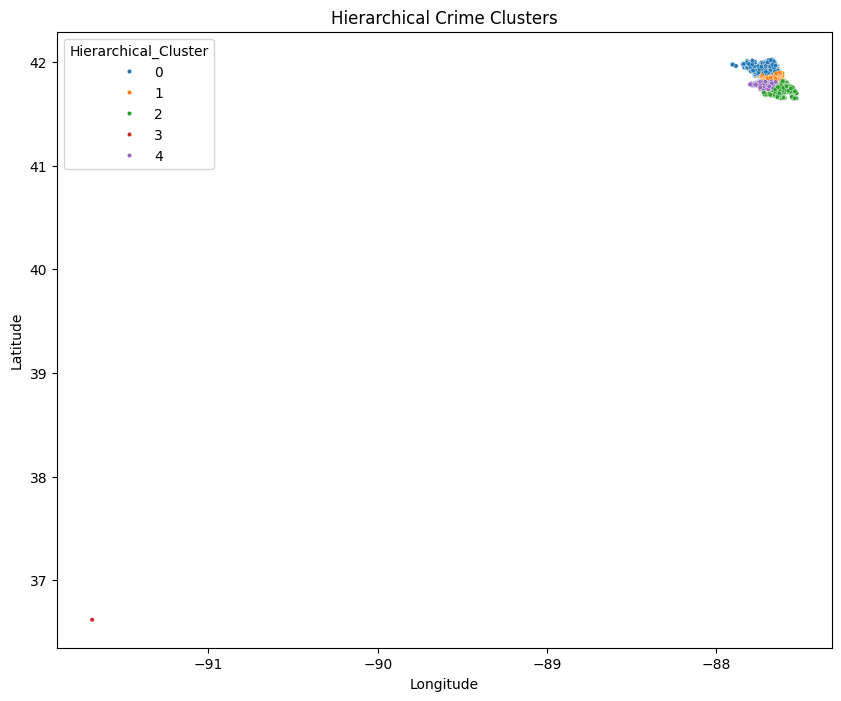

In [87]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    x=cluster_sample_small['Longitude'],
    y=cluster_sample_small['Latitude'],
    hue=cluster_sample_small['Hierarchical_Cluster'],
    palette='tab10',
    s=10
)

plt.title("Hierarchical Crime Clusters")
plt.show()

In [88]:
cluster_sample.to_csv(
    "/Users/sabari/Documents/DS/GUVI/dspatrol/PatrolIQ-Smart_Safety_Analytics_Platform-main/data/crime_hotspot_clusters.csv",
    index=False
)

print("Cluster Dataset Saved ✅")

Cluster Dataset Saved ✅


In [89]:
import joblib

joblib.dump(kmeans, "/Users/sabari/Documents/DS/GUVI/dspatrol/PatrolIQ-Smart_Safety_Analytics_Platform-main/models/kmeans_model.pkl")

print("KMeans model saved ✅")

KMeans model saved ✅


In [90]:
joblib.dump(db, "/Users/sabari/Documents/DS/GUVI/dspatrol/PatrolIQ-Smart_Safety_Analytics_Platform-main/models/dbscan_model.pkl")

print("DBSCAN model saved ✅")

DBSCAN model saved ✅


In [91]:
import mlflow
import os

mlflow.set_tracking_uri("file://" + os.path.abspath("../mlflow"))

In [92]:
mlflow.set_experiment("PatrolIQ_Clustering")

<Experiment: artifact_location='file:///Users/sabari/Documents/DS/GUVI/dspatrol/PatrolIQ-Smart_Safety_Analytics_Platform-main/mlflow/315545030475946501', creation_time=1775372491735, experiment_id='315545030475946501', last_update_time=1775372491735, lifecycle_stage='active', name='PatrolIQ_Clustering', tags={}, workspace='default'>